# Lab: Reinforcement Learning for PushCube-v1

## Learning Objectives
1. Understand the **RL loop**: agent observes state, takes action, receives reward
2. Build a **policy network** (actor) and **value network** (critic) from scratch with PyTorch
3. Implement **PPO (Proximal Policy Optimization)** — the most popular RL algorithm
4. Train an agent to push a cube to a goal position in ManiSkill3 simulator
5. Visualize and compare: random policy vs. hand-crafted policy vs. learned policy

## Environment: PushCube-v1
```
Task     : Panda robot arm pushes a cube to a goal position on a table
Obs      : 25-dim state vector (joint angles, velocities, gripper, cube pos, goal pos)
Action   : 7-dim (dx, dy, dz, droll, dpitch, dyaw, gripper)
Reward   : Dense — closer to goal = higher reward each step
Success  : Cube reaches within threshold of goal position
```

## Outline
1. Environment setup & exploration
2. Random policy baseline
3. Hand-crafted (heuristic) policy
4. PPO from scratch with PyTorch
5. Training loop
6. Evaluation & comparison

---
## Part 1: Setup & Imports

In [1]:
import gymnasium as gym
import mani_skill.envs
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import time
import warnings

warnings.filterwarnings("ignore")

# Check hardware
print("=" * 50)
print("  Hardware Check")
print("=" * 50)
print(f"  PyTorch : {torch.__version__}")
print(f"  CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU     : {torch.cuda.get_device_name(0)}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"  Device  : {device}")
print("=" * 50)

  Hardware Check
  PyTorch : 2.10.0+cu130
  CUDA    : True
  GPU     : NVIDIA GeForce RTX 5090
  Device  : cuda


---
## Part 2: Helper Functions

In [2]:
from mani_skill.utils.wrappers.gymnasium import CPUGymWrapper
import mediapy as media


def make_env(env_id="PushCube-v1", obs_mode="state", control_mode="pd_ee_delta_pose"):
    """Create a single CPU environment for learning and evaluation."""
    env = gym.make(
        env_id,
        num_envs=1,
        obs_mode=obs_mode,
        control_mode=control_mode,
        render_mode="rgb_array",
    )
    env = CPUGymWrapper(env)
    return env


def to_uint8(frame):
    """Safely convert a frame to uint8 numpy array."""
    if isinstance(frame, torch.Tensor):
        frame = frame.cpu().numpy()
    if frame.ndim == 4:
        frame = frame[0]
    if frame.dtype in (np.float32, np.float64):
        frame = (frame * 255).clip(0, 255).astype(np.uint8)
    return frame


def render_frame(env, width=512, height=512):
    """Render current frame as a PIL Image."""
    frame = to_uint8(env.render())
    return Image.fromarray(frame).resize((width, height))


def collect_episode(env, policy_fn, max_steps=200):
    """
    Run one episode with a given policy function.

    Args:
        env: gymnasium environment
        policy_fn: function(obs) -> action (numpy array)
        max_steps: maximum steps per episode

    Returns:
        frames, rewards, observations, actions, infos
    """
    frames, rewards, observations, actions, infos = [], [], [], [], []
    obs, info = env.reset()
    frames.append(to_uint8(env.render()))

    for step in range(max_steps):
        action = policy_fn(obs)
        obs_next, reward, terminated, truncated, info = env.step(action)

        frames.append(to_uint8(env.render()))
        rewards.append(float(reward))
        observations.append(obs)
        actions.append(action)
        infos.append(info)

        obs = obs_next
        if terminated or truncated:
            break

    return frames, rewards, observations, actions, infos


def plot_rewards(rewards, title="Reward per Step", color="steelblue"):
    """Plot reward curve for a single episode."""
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(rewards, linewidth=1.0, color=color)
    ax.fill_between(range(len(rewards)), rewards, alpha=0.15, color=color)
    ax.set_xlabel("Step")
    ax.set_ylabel("Reward")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
    print(f"  Total reward : {sum(rewards):.4f}")
    print(f"  Mean reward  : {np.mean(rewards):.4f}")
    print(f"  Max reward   : {max(rewards):.4f}")
    print(f"  Steps        : {len(rewards)}")


print("Helper functions ready.")

Helper functions ready.


---
## Part 3: Explore the PushCube-v1 Environment

Before training, we need to understand **what the agent sees** (observations)
and **what it can do** (actions).

### Observation Space (35 dimensions)
```
Index  0- 6 : joint_positions (7)    — angles of the 7 robot joints
Index  7- 8 : gripper_state (2)      — how open/closed each gripper finger is
Index  9-15 : joint_velocities (7)   — angular velocities of joints
Index 16-17 : gripper_velocities (2) — velocity of gripper fingers
Index 18-20 : tcp_position (3)       — x, y, z of end-effector (tool center point)
Index 21-24 : tcp_quaternion (4)     — orientation of end-effector
Index 25-27 : cube_position (3)      — x, y, z position of the cube
Index 28-30 : goal_position (3)      — x, y, z of the target location
Index 31-34 : cube_quaternion (4)    — orientation of the cube
```

### Action Space (7 dimensions)
Using `pd_ee_delta_pose` control mode:
```
action[0] = dx     — move end-effector in x
action[1] = dy     — move end-effector in y
action[2] = dz     — move end-effector in z
action[3] = droll  — rotate end-effector (roll)
action[4] = dpitch — rotate end-effector (pitch)
action[5] = dyaw   — rotate end-effector (yaw)
action[6] = gripper — open(negative) / close(positive) gripper
```

  PushCube-v1 Environment Info
  Observation space shape : (35,)
  Action space shape      : (7,)
  Action low              : [-1. -1. -1.]...
  Action high             : [1. 1. 1.]...

  Observation breakdown:
    obs[ 0: 7] joint_pos    = [ 0.01   0.39   0.013 -1.933 -0.005  2.352  0.817]
    obs[ 7: 9] gripper      = [0.04 0.04]
    obs[ 9:16] joint_vel    = [0. 0. 0. 0. 0. 0. 0.]
    obs[16:18] gripper_vel  = [0. 0.]
    obs[18:21] tcp_pos      = [0.012 0.014 0.184]
    obs[21:25] tcp_quat     = [-0.001  1.    -0.003  0.014]
    obs[25:28] cube_pos     = [0.276 0.083 0.001]
    obs[28:31] goal_pos     = [0.076 0.083 0.02 ]
    obs[31:35] cube_quat    = [1. 0. 0. 0.]


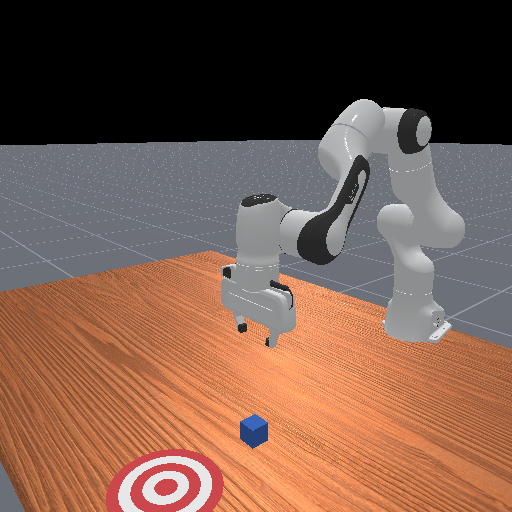

In [3]:
# 3.1 Create environment and inspect spaces
env = make_env("PushCube-v1")
obs, info = env.reset(seed=42)

print("=" * 55)
print("  PushCube-v1 Environment Info")
print("=" * 55)
print(f"  Observation space shape : {env.observation_space.shape}")
print(f"  Action space shape      : {env.action_space.shape}")
print(f"  Action low              : {env.action_space.low[:3]}...")
print(f"  Action high             : {env.action_space.high[:3]}...")
print()
print("  Observation breakdown:")
print(f"    obs[ 0: 7] joint_pos    = {obs[0:7].round(3)}")
print(f"    obs[ 7: 9] gripper      = {obs[7:9].round(3)}")
print(f"    obs[ 9:16] joint_vel    = {obs[9:16].round(3)}")
print(f"    obs[16:18] gripper_vel  = {obs[16:18].round(3)}")
print(f"    obs[18:21] tcp_pos      = {obs[18:21].round(3)}")
print(f"    obs[21:25] tcp_quat     = {obs[21:25].round(3)}")
print(f"    obs[25:28] cube_pos     = {obs[25:28].round(3)}")
print(f"    obs[28:31] goal_pos     = {obs[28:31].round(3)}")
print(f"    obs[31:35] cube_quat    = {obs[31:35].round(3)}")
print("=" * 55)

# 3.2 Render initial state
img = render_frame(env)
display(img)

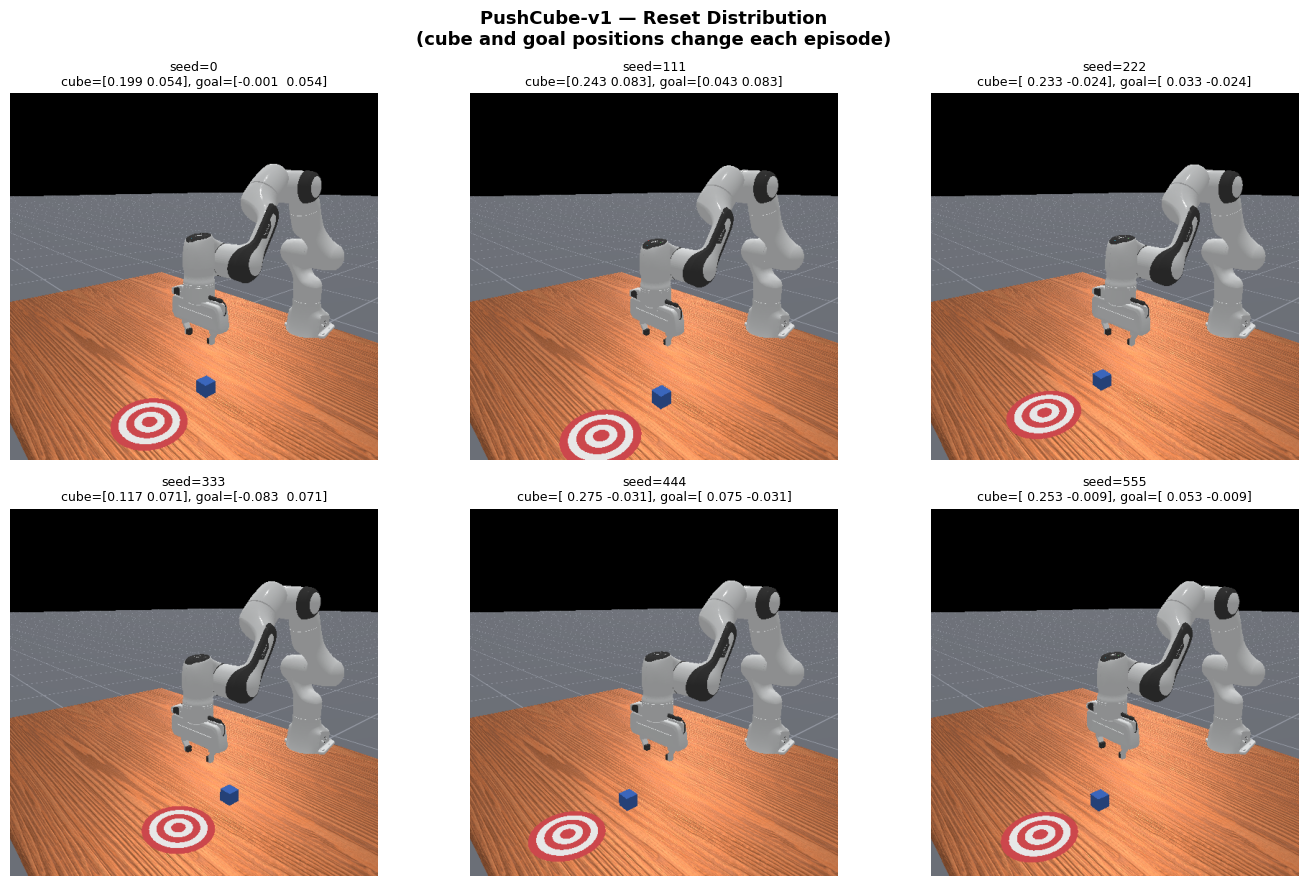

In [4]:
# 3.3 Visualize different initial states (reset distribution)
# The cube and goal positions are randomized each episode — the agent
# must learn to generalize, not memorize one configuration.

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for i, ax in enumerate(axes.flat):
    obs, _ = env.reset(seed=i * 111)
    frame = to_uint8(env.render())
    ax.imshow(frame)
    cube_xy = obs[25:27].round(3)
    goal_xy = obs[28:30].round(3)
    ax.set_title(f"seed={i*111}\ncube={cube_xy}, goal={goal_xy}", fontsize=9)
    ax.axis("off")
fig.suptitle("PushCube-v1 — Reset Distribution\n"
             "(cube and goal positions change each episode)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

env.close()

---
## Part 4: Experiment 1 — Random Policy (Baseline)

The simplest "policy" — sample random actions every step.
This shows what happens with **no intelligence at all**.
We expect very low reward because random movements rarely push
the cube toward the goal.

This browser does not support the video tag.


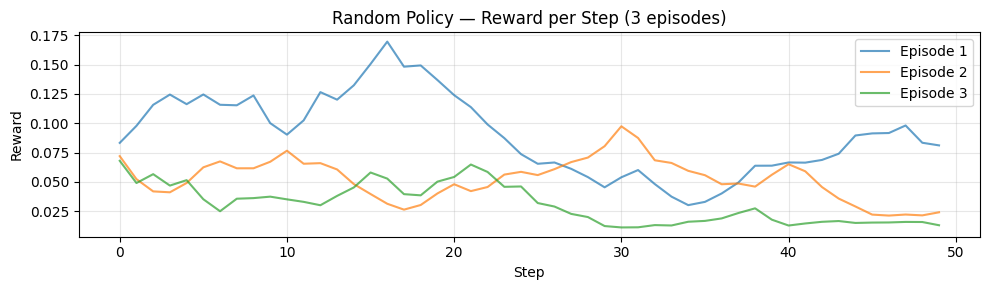


  Random Policy — Mean total reward over 3 episodes: 2.9076


In [5]:
env = make_env("PushCube-v1")


def random_policy(obs):
    """Randomly sample an action — no intelligence."""
    return env.action_space.sample()


# Run 3 episodes and collect results
random_rewards_all = []
for ep in range(3):
    frames, rewards, _, _, _ = collect_episode(env, random_policy, max_steps=200)
    random_rewards_all.append(rewards)
    if ep == 0:
        media.show_video(frames, fps=20)  # show video of first episode

# Plot all 3 episodes
fig, ax = plt.subplots(figsize=(10, 3))
for i, rews in enumerate(random_rewards_all):
    ax.plot(rews, alpha=0.7, label=f"Episode {i+1}")
ax.set_xlabel("Step")
ax.set_ylabel("Reward")
ax.set_title("Random Policy — Reward per Step (3 episodes)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

random_mean = np.mean([sum(r) for r in random_rewards_all])
print(f"\n  Random Policy — Mean total reward over 3 episodes: {random_mean:.4f}")

env.close()

---
## Part 5: Experiment 2 — Hand-Crafted (Heuristic) Policy

Before using RL, let's try a **simple rule-based policy** that uses
domain knowledge:

**Strategy:**
1. Move the gripper down toward the cube's position
2. Push the cube toward the goal by moving in the goal direction

This helps us understand **what a good policy should do** and gives
us an upper baseline to compare RL against.

This browser does not support the video tag.


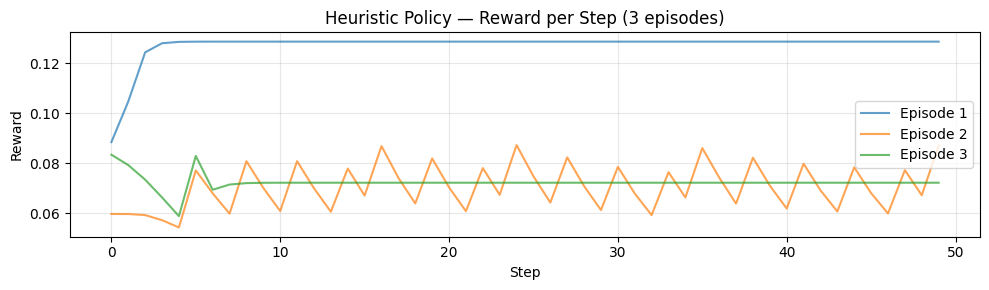


  Heuristic Policy — Mean total reward over 3 episodes: 4.5016
  Improvement over random: +1.5940


In [6]:
env = make_env("PushCube-v1")


def heuristic_policy(obs):
    """
    Hand-crafted policy using knowledge of observation structure.

    Strategy:
    - Extract tcp (end-effector), cube, and goal positions from obs
    - Move end-effector behind the cube (opposite side from goal)
    - Then push toward goal
    """
    tcp_pos  = obs[18:21]   # x, y, z of end-effector
    cube_pos = obs[25:28]   # x, y, z of cube
    goal_pos = obs[28:31]   # x, y, z of goal

    # Direction from cube to goal
    push_dir = goal_pos[:2] - cube_pos[:2]
    push_dist = np.linalg.norm(push_dir) + 1e-8
    push_dir_norm = push_dir / push_dist

    # Desired approach position: behind the cube (opposite to push direction)
    approach_pos = cube_pos.copy()
    approach_pos[0] -= push_dir_norm[0] * 0.03
    approach_pos[1] -= push_dir_norm[1] * 0.03
    approach_pos[2] = cube_pos[2] + 0.005  # slightly above cube

    # Actions are DELTA positions (pd_ee_delta_pose mode)
    # so we compute desired_pos - current_pos
    action = np.zeros(7, dtype=np.float32)

    # Distance from tcp to approach position
    tcp_to_approach = approach_pos - tcp_pos
    dist_to_cube = np.linalg.norm(tcp_pos[:2] - cube_pos[:2])

    if dist_to_cube > 0.04:
        # Phase 1: Move toward the approach position (behind cube)
        gain = 5.0
        action[0] = tcp_to_approach[0] * gain
        action[1] = tcp_to_approach[1] * gain
        action[2] = tcp_to_approach[2] * gain
    else:
        # Phase 2: Push through the cube toward the goal
        gain = 3.0
        action[0] = push_dir_norm[0] * gain
        action[1] = push_dir_norm[1] * gain
        action[2] = (cube_pos[2] - tcp_pos[2]) * gain  # stay at cube height

    action[6] = -1.0   # keep gripper open (push, don't grasp)

    return np.clip(action, -1.0, 1.0)


# Run 3 episodes
heuristic_rewards_all = []
for ep in range(3):
    frames, rewards, _, _, _ = collect_episode(env, heuristic_policy, max_steps=200)
    heuristic_rewards_all.append(rewards)
    if ep == 0:
        media.show_video(frames, fps=20)

# Plot
fig, ax = plt.subplots(figsize=(10, 3))
for i, rews in enumerate(heuristic_rewards_all):
    ax.plot(rews, alpha=0.7, label=f"Episode {i+1}")
ax.set_xlabel("Step")
ax.set_ylabel("Reward")
ax.set_title("Heuristic Policy — Reward per Step (3 episodes)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

heuristic_mean = np.mean([sum(r) for r in heuristic_rewards_all])
print(f"\n  Heuristic Policy — Mean total reward over 3 episodes: {heuristic_mean:.4f}")
print(f"  Improvement over random: {heuristic_mean - random_mean:+.4f}")

env.close()

---
## Part 6: Understanding PPO — The Algorithm

**PPO (Proximal Policy Optimization)** is the most widely used RL algorithm.
It learns a **policy** (what action to take) and a **value function**
(how good is this state) simultaneously.

### Key Concepts

```
┌─────────────────────────────────────────────────────┐
│                    PPO Overview                      │
│                                                      │
│  ┌──────────┐    obs    ┌──────────────┐             │
│  │          │ ────────► │ Actor Network │──► action   │
│  │   Env    │           │ (Policy)      │             │
│  │          │ ────────► │ Critic Network│──► value    │
│  │          │    obs    │ (Value fn)     │             │
│  └──────────┘           └──────────────┘             │
│       │                       ▲                       │
│       │ reward, done          │ update                │
│       └───────────────────────┘                       │
└─────────────────────────────────────────────────────┘
```

### PPO Loss Functions

**Actor (Policy) Loss** — maximize expected reward while staying close
to the old policy:
```
ratio = new_prob / old_prob
L_clip = min(ratio * advantage,
             clip(ratio, 1-eps, 1+eps) * advantage)
```
The clipping prevents the policy from changing too much in one update.

**Critic (Value) Loss** — predict how much total reward we'll get:
```
L_value = MSE(predicted_value, actual_return)
```

**Entropy Bonus** — encourage exploration by keeping actions diverse:
```
L_entropy = -mean(entropy(action_distribution))
```

### Why PPO?
- **Stable** — clipping prevents catastrophic updates
- **Simple** — easy to implement compared to TRPO, SAC
- **Effective** — state-of-the-art for many continuous control tasks
- **On-policy** — uses fresh data, easy to parallelize

---
## Part 7: Build the Neural Networks

We build two networks:
- **Actor**: takes observation → outputs mean & std of action distribution
- **Critic**: takes observation → outputs a single value (expected return)

In [7]:
class ActorCritic(nn.Module):
    """
    Combined Actor-Critic network for PPO.

    Architecture:
        Shared layers → Actor head (mean, log_std)
                      → Critic head (value)

    Using shared layers saves parameters and helps both networks
    learn useful features from observations.
    """

    def __init__(self, obs_dim, act_dim, hidden_dim=256):
        super().__init__()

        # Shared feature extractor
        # obs(35) → 256 → 256
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )

        # Actor head: outputs mean of action distribution
        # 256 → 128 → action_dim
        self.actor_mean = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, act_dim),
        )

        # Learnable log standard deviation (one per action dimension)
        # Start with log(1.0) = 0 so initial std = 1.0 (good exploration)
        # The network will learn to reduce std as it gets more confident
        self.actor_log_std = nn.Parameter(torch.zeros(act_dim))

        # Critic head: outputs state value
        # 256 → 128 → 1
        self.critic = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, obs):
        """Forward pass through shared layers."""
        features = self.shared(obs)
        return features

    def get_action_and_value(self, obs, action=None):
        """
        Get action from policy and value from critic.

        If action is None: sample a new action (for data collection).
        If action is given: compute log_prob of that action (for training).

        Returns:
            action, log_prob, entropy, value
        """
        features = self.forward(obs)

        # Actor: get action distribution
        action_mean = self.actor_mean(features)
        action_std = self.actor_log_std.exp().expand_as(action_mean)
        dist = torch.distributions.Normal(action_mean, action_std)

        if action is None:
            action = dist.sample()

        # Log probability of the action (sum over action dimensions)
        log_prob = dist.log_prob(action).sum(dim=-1)

        # Entropy for exploration bonus
        entropy = dist.entropy().sum(dim=-1)

        # Critic: get state value
        value = self.critic(features).squeeze(-1)

        return action, log_prob, entropy, value

    def get_value(self, obs):
        """Get value only (for computing advantages)."""
        features = self.forward(obs)
        return self.critic(features).squeeze(-1)


# Quick test
_test_model = ActorCritic(obs_dim=35, act_dim=7).to(device)
_test_obs = torch.randn(1, 35).to(device)
_test_action, _test_logp, _test_ent, _test_val = _test_model.get_action_and_value(_test_obs)

print("ActorCritic Network Test:")
print(f"  Input obs shape    : {_test_obs.shape}")
print(f"  Output action shape: {_test_action.shape}")
print(f"  Log prob           : {_test_logp.item():.4f}")
print(f"  Entropy            : {_test_ent.item():.4f}")
print(f"  Value              : {_test_val.item():.4f}")
print(f"  Total parameters   : {sum(p.numel() for p in _test_model.parameters()):,}")

ActorCritic Network Test:
  Input obs shape    : torch.Size([1, 35])
  Output action shape: torch.Size([1, 7])
  Log prob           : -10.5476
  Entropy            : 9.9326
  Value              : -0.0421
  Total parameters   : 141,839


In [8]:
# ============================================================
#  Observation Normalizer (Running Mean & Std)
# ============================================================
#
# WHY IS THIS NEEDED?
# The 25-dim observation has wildly different scales:
#   - joint_positions:  ~[-3, 3]     (radians)
#   - joint_velocities: ~[-10, 10]   (rad/s)
#   - gripper_state:    ~[0, 0.04]   (meters, very small!)
#   - cube_position:    ~[-0.3, 0.3] (meters)
#   - goal_position:    ~[-0.3, 0.3] (meters)
#
# Without normalization, the network treats all dimensions equally
# but a gradient step that helps joint_pos might hurt gripper_state.
# Normalizing to ~N(0,1) fixes this.


class RunningMeanStd:
    """
    Track running mean and std of observations for normalization.

    Uses Welford's online algorithm — numerically stable.
    Updates every time we see new data.
    """

    def __init__(self, shape):
        self.mean = np.zeros(shape, dtype=np.float64)
        self.var = np.ones(shape, dtype=np.float64)
        self.count = 1e-4  # small epsilon to avoid division by zero

    def update(self, x):
        """Update running statistics with a new observation."""
        batch_mean = np.mean(x, axis=0) if x.ndim > 1 else x
        batch_var = np.var(x, axis=0) if x.ndim > 1 else np.zeros_like(x)
        batch_count = x.shape[0] if x.ndim > 1 else 1
        self._update_from_moments(batch_mean, batch_var, batch_count)

    def _update_from_moments(self, batch_mean, batch_var, batch_count):
        delta = batch_mean - self.mean
        total = self.count + batch_count
        new_mean = self.mean + delta * batch_count / total
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        m2 = m_a + m_b + delta**2 * self.count * batch_count / total
        self.mean = new_mean
        self.var = m2 / total
        self.count = total

    def normalize(self, x):
        """Normalize observation to approximately N(0, 1)."""
        return (x - self.mean.astype(np.float32)) / (
            np.sqrt(self.var.astype(np.float32)) + 1e-8
        )


# Quick test
_rms = RunningMeanStd(shape=(35,))
for _ in range(100):
    _fake_obs = np.random.randn(35) * ([3]*7 + [0.02]*2 + [10]*7 + [0.1]*2 + [0.1]*3 + [0.5]*4 + [0.1]*3 + [0.1]*3 + [0.5]*4)
    _rms.update(_fake_obs)
print(f"\nRunningMeanStd test — mean range: [{_rms.mean.min():.2f}, {_rms.mean.max():.2f}]")
print("Observation normalizer ready.")


RunningMeanStd test — mean range: [-1.89, 0.59]
Observation normalizer ready.


---
## Part 8: PPO Rollout Buffer

During training, we collect data by running the policy in the environment.
This data is stored in a **rollout buffer** and then used to update
the policy.

Each transition contains:
```
(observation, action, log_prob, reward, done, value)
```

In [9]:
class RolloutBuffer:
    """
    Stores transitions collected during rollout for PPO training.

    After collecting N steps, compute advantages using GAE
    (Generalized Advantage Estimation) and prepare mini-batches.
    """

    def __init__(self):
        self.observations = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def store(self, obs, action, log_prob, reward, done, value):
        """Store one transition."""
        self.observations.append(obs)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def clear(self):
        """Clear all stored data."""
        self.__init__()

    def compute_returns_and_advantages(self, last_value, gamma=0.99, gae_lambda=0.95):
        """
        Compute discounted returns and GAE advantages.

        GAE (Generalized Advantage Estimation):
            advantage_t = delta_t + (gamma * lambda) * delta_{t+1} + ...
            where delta_t = reward_t + gamma * V(s_{t+1}) - V(s_t)

        This balances bias vs variance in advantage estimation:
        - lambda=0 → high bias, low variance (just TD error)
        - lambda=1 → low bias, high variance (full Monte Carlo)
        - lambda=0.95 → good balance (standard choice)
        """
        rewards = np.array(self.rewards)
        dones = np.array(self.dones)
        values = np.array(self.values + [last_value])

        advantages = np.zeros_like(rewards)
        last_gae = 0

        for t in reversed(range(len(rewards))):
            next_non_terminal = 1.0 - dones[t]
            delta = rewards[t] + gamma * values[t + 1] * next_non_terminal - values[t]
            advantages[t] = last_gae = delta + gamma * gae_lambda * next_non_terminal * last_gae

        returns = advantages + np.array(self.values)

        return returns, advantages

    def get_batches(self, last_value, batch_size=64, gamma=0.99, gae_lambda=0.95):
        """
        Compute advantages, normalize them, and yield mini-batches.

        Normalizing advantages (zero mean, unit std) stabilizes training.
        """
        returns, advantages = self.compute_returns_and_advantages(
            last_value, gamma, gae_lambda
        )

        # Convert to tensors
        obs_t = torch.FloatTensor(np.array(self.observations)).to(device)
        act_t = torch.FloatTensor(np.array(self.actions)).to(device)
        logp_t = torch.FloatTensor(np.array(self.log_probs)).to(device)
        ret_t = torch.FloatTensor(returns).to(device)
        adv_t = torch.FloatTensor(advantages).to(device)

        # Normalize advantages
        adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)

        # Shuffle and create mini-batches
        n = len(self.observations)
        indices = np.random.permutation(n)

        for start in range(0, n, batch_size):
            end = start + batch_size
            idx = indices[start:end]
            yield (obs_t[idx], act_t[idx], logp_t[idx], ret_t[idx], adv_t[idx])


print("RolloutBuffer ready.")

RolloutBuffer ready.


---
## Part 9: PPO Training Loop

The training process:
1. **Collect rollout**: Run the current policy for N steps, store transitions
2. **Compute advantages**: How much better was each action vs. expected?
3. **Update policy**: Run multiple epochs of mini-batch gradient descent
4. **Repeat**

### Hyperparameters
| Parameter | Value | Why |
|---|---|---|
| `rollout_steps` | 2048 | Steps to collect before each update |
| `n_epochs` | 10 | Update epochs per rollout |
| `batch_size` | 256 | Mini-batch size for SGD |
| `lr` | 3e-4 | Adam learning rate (standard for PPO) |
| `gamma` | 0.99 | Discount factor (value future rewards) |
| `gae_lambda` | 0.95 | GAE smoothing (bias-variance tradeoff) |
| `clip_eps` | 0.2 | PPO clipping range |
| `ent_coef` | 0.01 | Entropy bonus (exploration) |
| `vf_coef` | 0.5 | Value loss weight |

In [10]:
# ============================================================
#  PPO Hyperparameters
# ============================================================
TOTAL_TIMESTEPS = 200_000    # Total env steps for training
ROLLOUT_STEPS   = 2048       # Steps per rollout before updating
N_EPOCHS        = 10         # Gradient epochs per rollout
BATCH_SIZE      = 256        # Mini-batch size
LR              = 3e-4       # Learning rate
GAMMA           = 0.99       # Discount factor
GAE_LAMBDA      = 0.95       # GAE lambda
CLIP_EPS        = 0.2        # PPO clip range
ENT_COEF        = 0.01       # Entropy coefficient
VF_COEF         = 0.5        # Value function coefficient
MAX_GRAD_NORM   = 0.5        # Gradient clipping

print("PPO Hyperparameters:")
print(f"  Total timesteps  : {TOTAL_TIMESTEPS:,}")
print(f"  Rollout steps    : {ROLLOUT_STEPS:,}")
print(f"  Epochs per update: {N_EPOCHS}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Learning rate    : {LR}")
print(f"  Gamma            : {GAMMA}")
print(f"  GAE lambda       : {GAE_LAMBDA}")
print(f"  Clip epsilon     : {CLIP_EPS}")
print(f"  Entropy coef     : {ENT_COEF}")
print(f"  Value fn coef    : {VF_COEF}")

PPO Hyperparameters:
  Total timesteps  : 200,000
  Rollout steps    : 2,048
  Epochs per update: 10
  Batch size       : 256
  Learning rate    : 0.0003
  Gamma            : 0.99
  GAE lambda       : 0.95
  Clip epsilon     : 0.2
  Entropy coef     : 0.01
  Value fn coef    : 0.5


In [11]:
# ============================================================
#  Training Function
# ============================================================

def train_ppo(total_timesteps=TOTAL_TIMESTEPS, lr=LR, seed=42):
    """
    Train PPO on PushCube-v1 and return training history.

    Args:
        total_timesteps: total environment steps
        lr: learning rate for Adam optimizer
        seed: random seed

    Returns:
        model: trained ActorCritic
        obs_rms: RunningMeanStd for observation normalization (needed at eval)
        history: dict with episode_rewards, policy_losses, value_losses, etc.
    """
    # ---- Setup ----
    env = make_env("PushCube-v1")
    obs_dim = env.observation_space.shape[0]  # 25
    act_dim = env.action_space.shape[0]       # 7

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = ActorCritic(obs_dim, act_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, eps=1e-5)

    # Observation normalizer — critical for continuous control!
    # Without this, obs dimensions with large values dominate gradients.
    obs_rms = RunningMeanStd(shape=(obs_dim,))

    # ---- Tracking ----
    history = {
        "episode_rewards": [],
        "episode_lengths": [],
        "policy_losses": [],
        "value_losses": [],
        "entropies": [],
        "approx_kl": [],
    }

    # ---- Training loop ----
    obs, _ = env.reset(seed=seed)
    episode_reward = 0.0
    episode_length = 0
    global_step = 0
    n_updates = 0

    print("\n" + "=" * 60)
    print(f"  PPO Training — {total_timesteps:,} steps, lr={lr}")
    print("=" * 60)
    start_time = time.time()

    while global_step < total_timesteps:
        buffer = RolloutBuffer()
        model.eval()

        # ---- Collect rollout ----
        for step in range(ROLLOUT_STEPS):
            global_step += 1

            # Normalize observation before feeding to network
            obs_rms.update(obs)
            obs_norm = obs_rms.normalize(obs)
            obs_tensor = torch.FloatTensor(obs_norm).unsqueeze(0).to(device)

            with torch.no_grad():
                action, log_prob, _, value = model.get_action_and_value(obs_tensor)

            # CRITICAL: store the RAW sampled action (matches log_prob)
            # Only clip for the env.step() call
            action_raw = action.squeeze(0).cpu().numpy()
            action_clipped = np.clip(action_raw, env.action_space.low, env.action_space.high)

            obs_next, reward, terminated, truncated, info = env.step(action_clipped)
            done = terminated or truncated

            buffer.store(
                obs=obs_norm.copy(),    # normalized obs
                action=action_raw,      # raw action (consistent with log_prob!)
                log_prob=log_prob.item(),
                reward=reward,
                done=float(done),
                value=value.item(),
            )

            episode_reward += reward
            episode_length += 1
            obs = obs_next

            if done:
                history["episode_rewards"].append(episode_reward)
                history["episode_lengths"].append(episode_length)
                episode_reward = 0.0
                episode_length = 0
                obs, _ = env.reset()

        # ---- Compute last value for GAE ----
        with torch.no_grad():
            last_obs_norm = obs_rms.normalize(obs)
            last_obs_tensor = torch.FloatTensor(last_obs_norm).unsqueeze(0).to(device)
            last_value = model.get_value(last_obs_tensor).item()

        # ---- PPO Update ----
        model.train()

        epoch_policy_losses = []
        epoch_value_losses = []
        epoch_entropies = []
        epoch_kl = []

        for epoch in range(N_EPOCHS):
            for batch in buffer.get_batches(last_value, BATCH_SIZE, GAMMA, GAE_LAMBDA):
                b_obs, b_act, b_logp_old, b_ret, b_adv = batch

                # Forward pass with current policy
                _, new_log_prob, entropy, new_value = model.get_action_and_value(
                    b_obs, b_act
                )

                # ---- Policy loss (clipped surrogate) ----
                log_ratio = new_log_prob - b_logp_old
                ratio = log_ratio.exp()

                # Approximate KL divergence for monitoring
                with torch.no_grad():
                    approx_kl = ((ratio - 1) - log_ratio).mean().item()

                surr1 = ratio * b_adv
                surr2 = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * b_adv
                policy_loss = -torch.min(surr1, surr2).mean()

                # ---- Value loss ----
                value_loss = ((new_value - b_ret) ** 2).mean()

                # ---- Entropy bonus ----
                entropy_loss = -entropy.mean()

                # ---- Total loss ----
                loss = policy_loss + VF_COEF * value_loss + ENT_COEF * entropy_loss

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()

                epoch_policy_losses.append(policy_loss.item())
                epoch_value_losses.append(value_loss.item())
                epoch_entropies.append(-entropy_loss.item())
                epoch_kl.append(approx_kl)

        n_updates += 1
        history["policy_losses"].append(np.mean(epoch_policy_losses))
        history["value_losses"].append(np.mean(epoch_value_losses))
        history["entropies"].append(np.mean(epoch_entropies))
        history["approx_kl"].append(np.mean(epoch_kl))

        # ---- Logging ----
        if len(history["episode_rewards"]) > 0:
            recent_rewards = history["episode_rewards"][-10:]
            elapsed = time.time() - start_time
            fps = global_step / elapsed
            print(
                f"  Step {global_step:>7,}/{total_timesteps:,} | "
                f"Update {n_updates:>3} | "
                f"Mean Reward (last 10): {np.mean(recent_rewards):>8.3f} | "
                f"Policy Loss: {history['policy_losses'][-1]:.4f} | "
                f"FPS: {fps:.0f}"
            )

    elapsed = time.time() - start_time
    print("=" * 60)
    print(f"  Training finished in {elapsed:.1f}s ({global_step/elapsed:.0f} FPS)")
    print(f"  Total updates : {n_updates}")
    print(f"  Total episodes: {len(history['episode_rewards'])}")
    if history["episode_rewards"]:
        print(f"  Best episode reward : {max(history['episode_rewards']):.4f}")
        print(f"  Last 10 mean reward : {np.mean(history['episode_rewards'][-10:]):.4f}")
    print("=" * 60)

    env.close()
    return model, obs_rms, history

---
## Part 10: Run Training

In [12]:
trained_model, trained_obs_rms, training_history = train_ppo(total_timesteps=TOTAL_TIMESTEPS)


  PPO Training — 200,000 steps, lr=0.0003
  Step   2,048/200,000 | Update   1 | Mean Reward (last 10):    2.761 | Policy Loss: -0.0312 | FPS: 567
  Step   4,096/200,000 | Update   2 | Mean Reward (last 10):    1.742 | Policy Loss: -0.0302 | FPS: 577
  Step   6,144/200,000 | Update   3 | Mean Reward (last 10):    4.028 | Policy Loss: -0.0367 | FPS: 574
  Step   8,192/200,000 | Update   4 | Mean Reward (last 10):    4.446 | Policy Loss: -0.0317 | FPS: 577
  Step  10,240/200,000 | Update   5 | Mean Reward (last 10):    4.502 | Policy Loss: -0.0283 | FPS: 578
  Step  12,288/200,000 | Update   6 | Mean Reward (last 10):    4.229 | Policy Loss: -0.0348 | FPS: 579
  Step  14,336/200,000 | Update   7 | Mean Reward (last 10):    4.462 | Policy Loss: -0.0320 | FPS: 578
  Step  16,384/200,000 | Update   8 | Mean Reward (last 10):    4.426 | Policy Loss: -0.0274 | FPS: 578
  Step  18,432/200,000 | Update   9 | Mean Reward (last 10):    5.228 | Policy Loss: -0.0240 | FPS: 578
  Step  20,480/200,00

---
## Part 11: Visualize Training Progress

Good training should show:
- **Episode rewards increasing** over time
- **Policy loss decreasing** then stabilizing
- **Value loss decreasing** (critic learns to predict returns)
- **Entropy decreasing** (policy becomes more confident)
- **KL divergence staying small** (updates are stable)

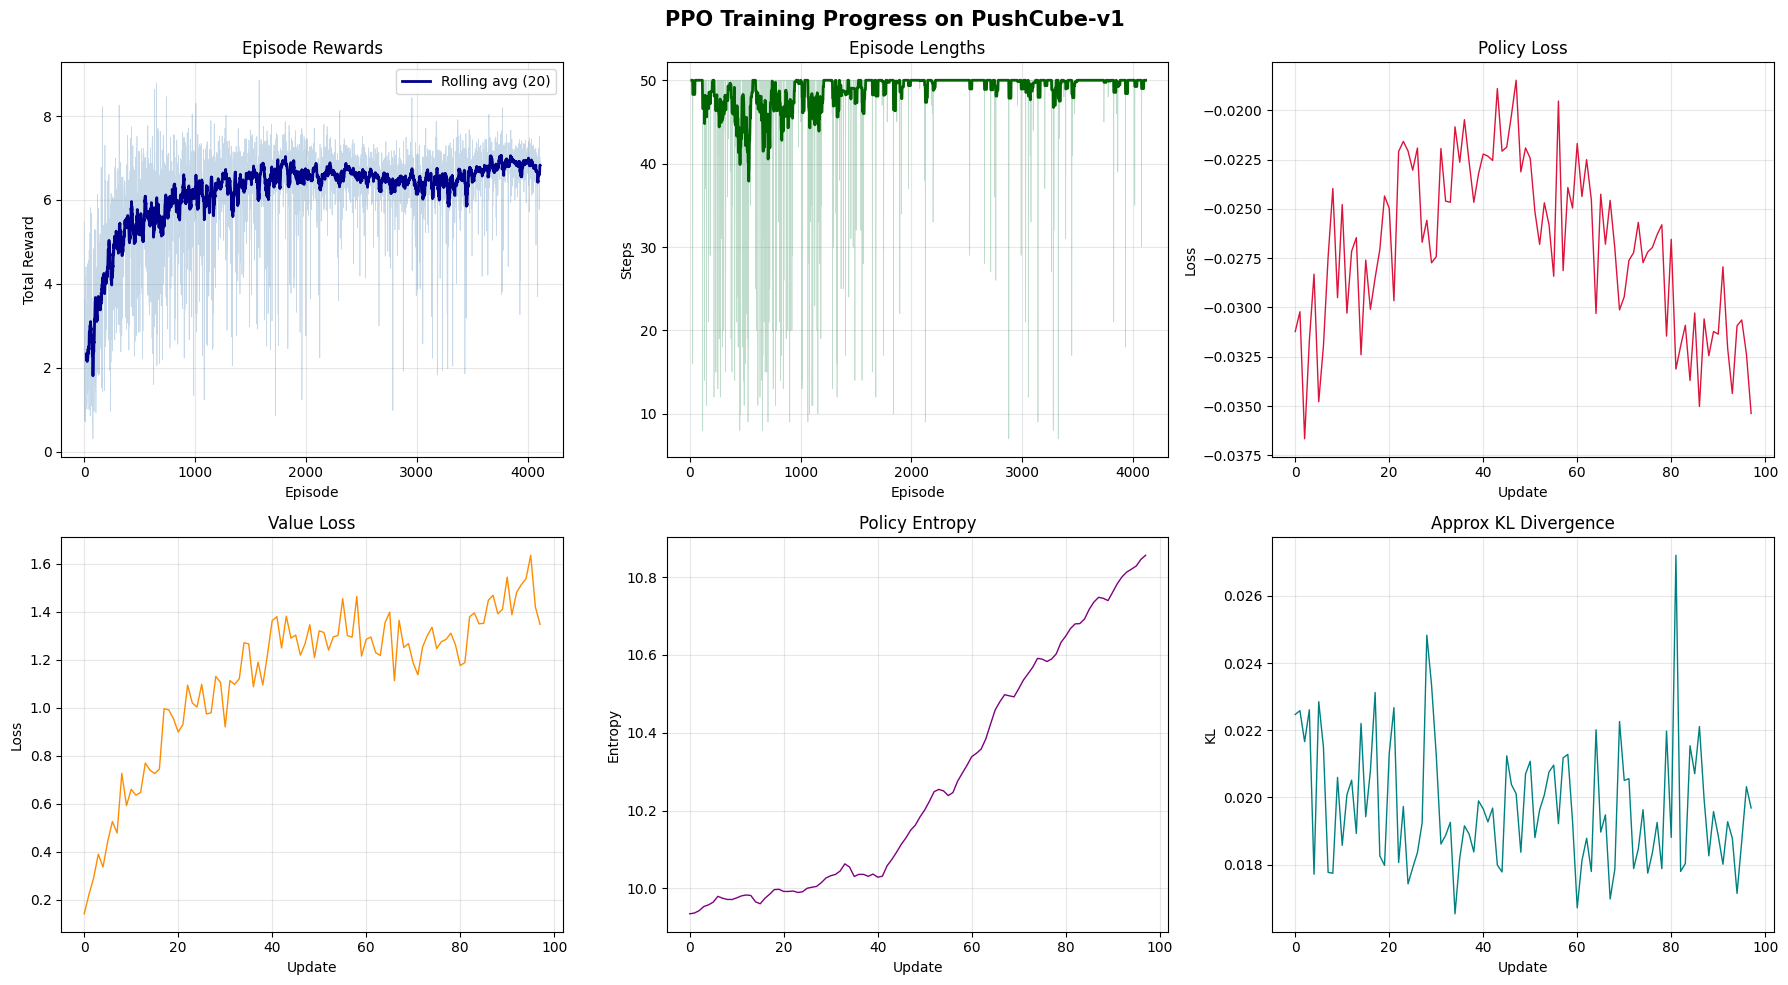

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Episode rewards
if training_history["episode_rewards"]:
    ep_rewards = training_history["episode_rewards"]
    axes[0, 0].plot(ep_rewards, alpha=0.3, color="steelblue", linewidth=0.5)
    # Rolling average
    window = min(20, len(ep_rewards))
    if len(ep_rewards) >= window:
        rolling = np.convolve(ep_rewards, np.ones(window)/window, mode="valid")
        axes[0, 0].plot(range(window-1, len(ep_rewards)), rolling,
                        color="darkblue", linewidth=2, label=f"Rolling avg ({window})")
    axes[0, 0].set_title("Episode Rewards")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Total Reward")
    axes[0, 0].legend()

# 2. Episode lengths
if training_history["episode_lengths"]:
    axes[0, 1].plot(training_history["episode_lengths"], alpha=0.3,
                    color="seagreen", linewidth=0.5)
    if len(training_history["episode_lengths"]) >= window:
        rolling_len = np.convolve(training_history["episode_lengths"],
                                  np.ones(window)/window, mode="valid")
        axes[0, 1].plot(range(window-1, len(training_history["episode_lengths"])),
                        rolling_len, color="darkgreen", linewidth=2)
    axes[0, 1].set_title("Episode Lengths")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Steps")

# 3. Policy loss
axes[0, 2].plot(training_history["policy_losses"], color="crimson", linewidth=1)
axes[0, 2].set_title("Policy Loss")
axes[0, 2].set_xlabel("Update")
axes[0, 2].set_ylabel("Loss")

# 4. Value loss
axes[1, 0].plot(training_history["value_losses"], color="darkorange", linewidth=1)
axes[1, 0].set_title("Value Loss")
axes[1, 0].set_xlabel("Update")
axes[1, 0].set_ylabel("Loss")

# 5. Entropy
axes[1, 1].plot(training_history["entropies"], color="purple", linewidth=1)
axes[1, 1].set_title("Policy Entropy")
axes[1, 1].set_xlabel("Update")
axes[1, 1].set_ylabel("Entropy")

# 6. KL divergence
axes[1, 2].plot(training_history["approx_kl"], color="teal", linewidth=1)
axes[1, 2].set_title("Approx KL Divergence")
axes[1, 2].set_xlabel("Update")
axes[1, 2].set_ylabel("KL")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

fig.suptitle("PPO Training Progress on PushCube-v1",
             fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

---
## Part 12: Evaluate Trained Policy

Now we test the trained model on new episodes and compare
with random and heuristic baselines.

In [17]:
env = make_env("PushCube-v1")

# Define trained policy function
def trained_policy(obs):
    """Use the trained ActorCritic to select actions (deterministic = use mean).
    IMPORTANT: must normalize obs using the same stats from training!"""
    obs_norm = trained_obs_rms.normalize(obs)
    obs_tensor = torch.FloatTensor(obs_norm).unsqueeze(0).to(device)
    with torch.no_grad():
        features = trained_model.forward(obs_tensor)
        action_mean = trained_model.actor_mean(features)
    action_np = action_mean.squeeze(0).cpu().numpy()
    return np.clip(action_np, env.action_space.low, env.action_space.high)


# Run evaluation episodes
print("=" * 55)
print("  Evaluating Trained Policy (5 episodes)")
print("=" * 55)

trained_rewards_all = []
for ep in range(20):
    frames, rewards, _, _, infos = collect_episode(env, trained_policy, max_steps=200)
    trained_rewards_all.append(rewards)
    total_r = sum(rewards)
    success = infos[-1].get("success", False) if infos else False
    print(f"  Episode {ep+1}: total_reward={total_r:.4f}, "
          f"steps={len(rewards)}, success={success}")
    if ep == 0:
        media.show_video(frames, fps=20)

trained_mean = np.mean([sum(r) for r in trained_rewards_all])
print(f"\n  Trained Policy — Mean total reward: {trained_mean:.4f}")

env.close()

  Evaluating Trained Policy (5 episodes)
  Episode 1: total_reward=7.2361, steps=50, success=False


This browser does not support the video tag.


  Episode 2: total_reward=7.0436, steps=50, success=False
  Episode 3: total_reward=7.4422, steps=50, success=False
  Episode 4: total_reward=7.7276, steps=50, success=False
  Episode 5: total_reward=7.4392, steps=50, success=False
  Episode 6: total_reward=7.2749, steps=50, success=False
  Episode 7: total_reward=7.2507, steps=50, success=False
  Episode 8: total_reward=7.4017, steps=50, success=False
  Episode 9: total_reward=7.4810, steps=50, success=False
  Episode 10: total_reward=7.3573, steps=50, success=False
  Episode 11: total_reward=7.3153, steps=50, success=False
  Episode 12: total_reward=7.2913, steps=50, success=False
  Episode 13: total_reward=7.3023, steps=50, success=False
  Episode 14: total_reward=7.3201, steps=50, success=False
  Episode 15: total_reward=7.1289, steps=50, success=False
  Episode 16: total_reward=7.5117, steps=50, success=False
  Episode 17: total_reward=7.4500, steps=50, success=False
  Episode 18: total_reward=7.2361, steps=50, success=False
  Epi

---
## Part 13: Final Comparison — Random vs Heuristic vs Trained

Side-by-side comparison of all three approaches.

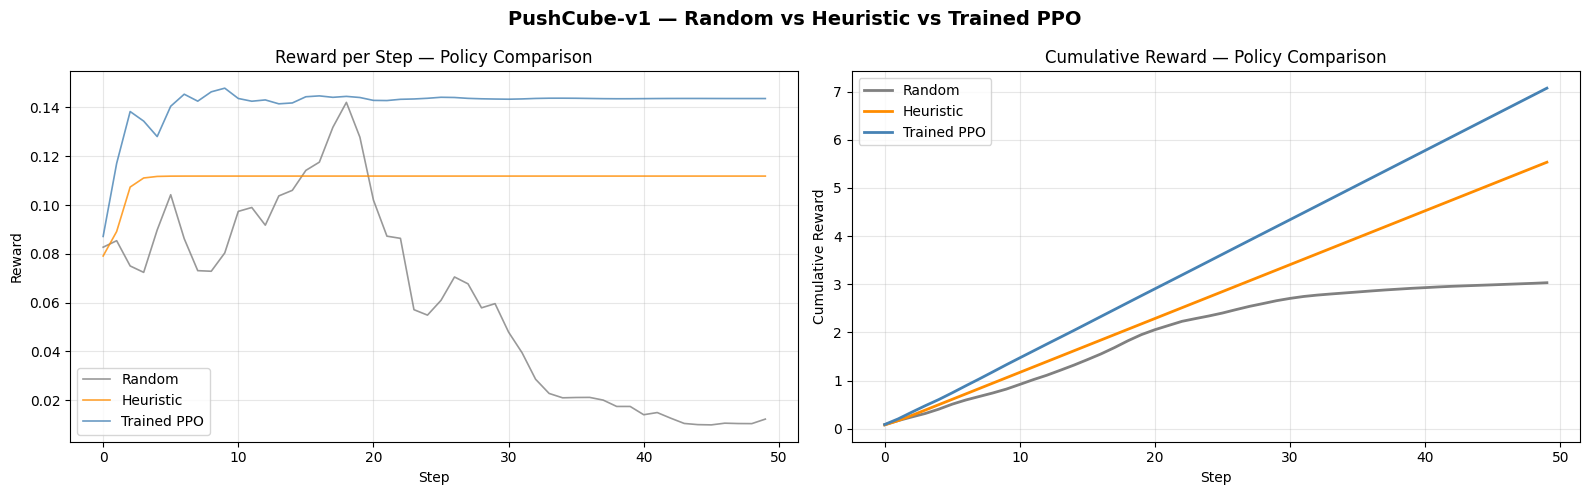


  Policy Comparison Summary
  Policy                 Total Reward    Mean/Step
  ------------------------------------------------
  Random                       3.0311       0.0606
  Heuristic                    5.5331       0.1107
  Trained PPO                  7.0710       0.1414


In [15]:
# Run fresh episodes for fair comparison
env = make_env("PushCube-v1")

comparison_results = {}

# Random
env.reset(seed=0)
_, rews_r, _, _, _ = collect_episode(env, random_policy, max_steps=200)
comparison_results["Random"] = rews_r

# Heuristic
env.reset(seed=0)
_, rews_h, _, _, _ = collect_episode(env, heuristic_policy, max_steps=200)
comparison_results["Heuristic"] = rews_h

# Trained PPO
env.reset(seed=0)
_, rews_t, _, _, _ = collect_episode(env, trained_policy, max_steps=200)
comparison_results["Trained PPO"] = rews_t

env.close()

# ---- Plot comparison ----
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {"Random": "gray", "Heuristic": "darkorange", "Trained PPO": "steelblue"}

# Left: reward per step
for name, rews in comparison_results.items():
    axes[0].plot(rews, label=name, color=colors[name], linewidth=1.2, alpha=0.8)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")
axes[0].set_title("Reward per Step — Policy Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: cumulative reward
for name, rews in comparison_results.items():
    cum = np.cumsum(rews)
    axes[1].plot(cum, label=name, color=colors[name], linewidth=2)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Cumulative Reward")
axes[1].set_title("Cumulative Reward — Policy Comparison")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("PushCube-v1 — Random vs Heuristic vs Trained PPO",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 55)
print("  Policy Comparison Summary")
print("=" * 55)
print(f"  {'Policy':<20s} {'Total Reward':>14s} {'Mean/Step':>12s}")
print("  " + "-" * 48)
for name, rews in comparison_results.items():
    print(f"  {name:<20s} {sum(rews):>14.4f} {np.mean(rews):>12.4f}")
print("=" * 55)

---
## Part 14: Experiment — Effect of Hyperparameters

Let's see how different learning rates affect training.
This teaches students that **hyperparameter tuning matters** in RL.


--- Training with lr=1e-4 (small) ---

  PPO Training — 50,000 steps, lr=0.0001
  Step   2,048/50,000 | Update   1 | Mean Reward (last 10):    2.761 | Policy Loss: -0.0294 | FPS: 599
  Step   4,096/50,000 | Update   2 | Mean Reward (last 10):    2.042 | Policy Loss: -0.0293 | FPS: 593
  Step   6,144/50,000 | Update   3 | Mean Reward (last 10):    3.437 | Policy Loss: -0.0280 | FPS: 592
  Step   8,192/50,000 | Update   4 | Mean Reward (last 10):    3.896 | Policy Loss: -0.0271 | FPS: 589
  Step  10,240/50,000 | Update   5 | Mean Reward (last 10):    4.258 | Policy Loss: -0.0295 | FPS: 585
  Step  12,288/50,000 | Update   6 | Mean Reward (last 10):    4.251 | Policy Loss: -0.0268 | FPS: 585
  Step  14,336/50,000 | Update   7 | Mean Reward (last 10):    5.291 | Policy Loss: -0.0283 | FPS: 585
  Step  16,384/50,000 | Update   8 | Mean Reward (last 10):    4.991 | Policy Loss: -0.0277 | FPS: 585
  Step  18,432/50,000 | Update   9 | Mean Reward (last 10):    5.134 | Policy Loss: -0.0248 | F

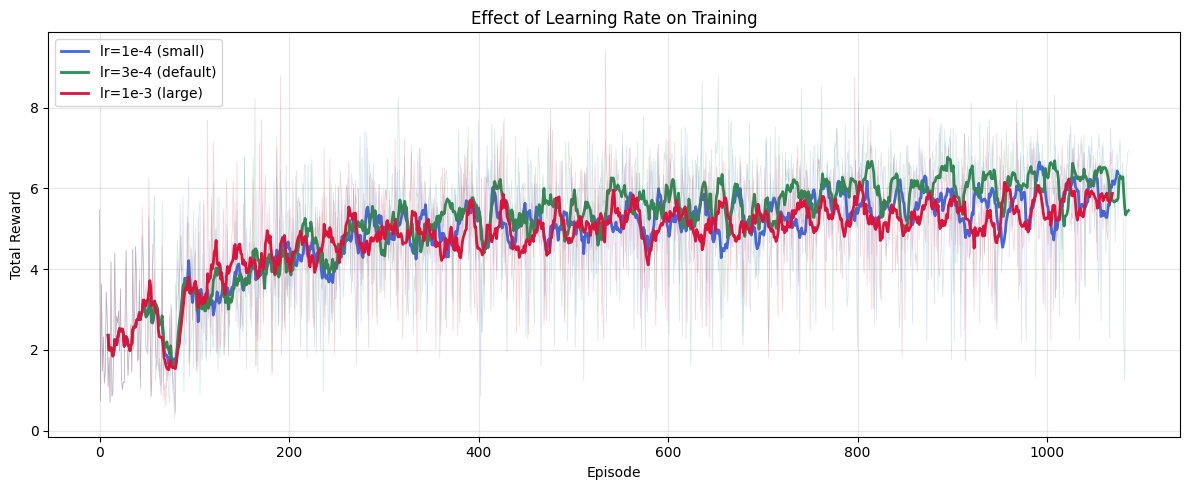

In [18]:
# Compare different learning rates
lr_experiments = {
    "lr=1e-4 (small)": 1e-4,
    "lr=3e-4 (default)": 3e-4,
    "lr=1e-3 (large)": 1e-3,
}

lr_results = {}

for name, lr_val in lr_experiments.items():
    print(f"\n--- Training with {name} ---")
    _, _, hist_lr = train_ppo(total_timesteps=50_000, lr=lr_val, seed=42)
    lr_results[name] = hist_lr

print("\nAll learning rate experiments done.")

# Plot comparison
if lr_results:
    fig, ax = plt.subplots(figsize=(12, 5))
    colors_lr = ["royalblue", "seagreen", "crimson"]
    for i, (name, hist) in enumerate(lr_results.items()):
        if hist["episode_rewards"]:
            ep_rews = hist["episode_rewards"]
            ax.plot(ep_rews, alpha=0.2, color=colors_lr[i], linewidth=0.5)
            # Rolling average
            w = min(10, len(ep_rews))
            if len(ep_rews) >= w:
                rolling = np.convolve(ep_rews, np.ones(w)/w, mode="valid")
                ax.plot(range(w-1, len(ep_rews)), rolling,
                        color=colors_lr[i], linewidth=2, label=name)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Total Reward")
    ax.set_title("Effect of Learning Rate on Training")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

---
## Part 15: Experiment — Observation Analysis

Let's look at **what the trained agent actually does** by plotting
the observation values and actions over time.

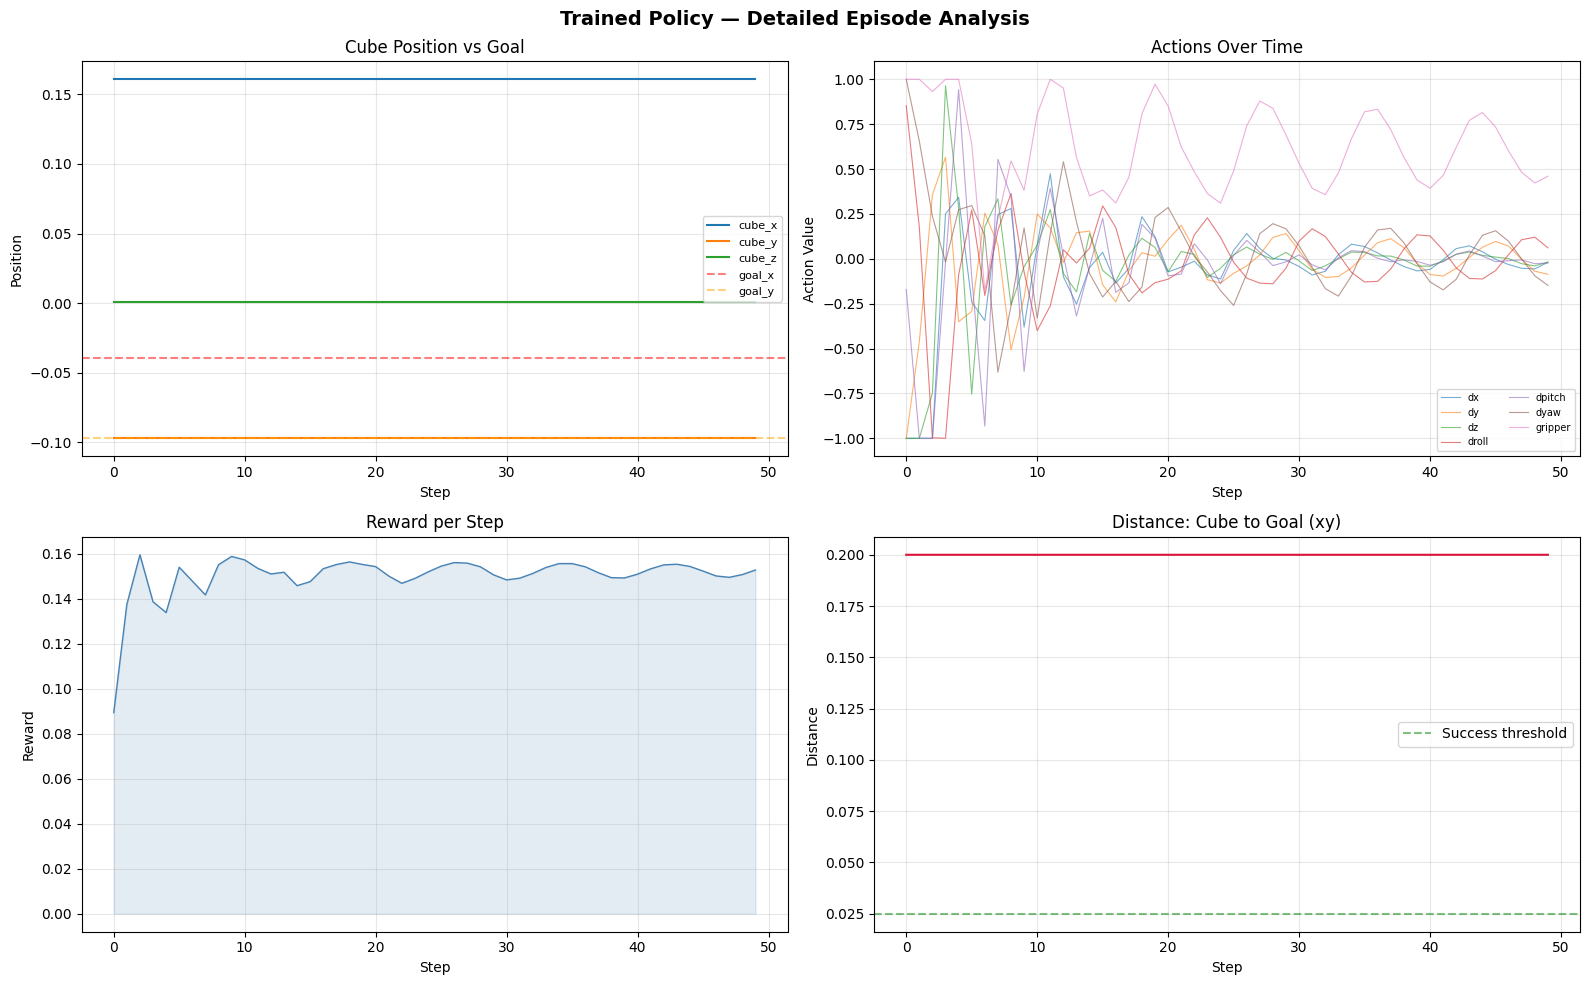

In [19]:
env = make_env("PushCube-v1")
obs, _ = env.reset(seed=42)

frames, rewards, observations, actions, infos = collect_episode(
    env, trained_policy, max_steps=200
)

obs_array = np.array(observations)
act_array = np.array(actions)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Cube position over time
axes[0, 0].plot(obs_array[:, 25], label="cube_x", linewidth=1.5)
axes[0, 0].plot(obs_array[:, 26], label="cube_y", linewidth=1.5)
axes[0, 0].plot(obs_array[:, 27], label="cube_z", linewidth=1.5)
# Goal position (constant)
axes[0, 0].axhline(y=obs_array[0, 28], color="red", linestyle="--",
                    alpha=0.5, label="goal_x")
axes[0, 0].axhline(y=obs_array[0, 29], color="orange", linestyle="--",
                    alpha=0.5, label="goal_y")
axes[0, 0].set_title("Cube Position vs Goal")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Position")
axes[0, 0].legend(fontsize=8)

# 2. Actions over time
action_labels = ["dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper"]
for i in range(7):
    axes[0, 1].plot(act_array[:, i], alpha=0.6, linewidth=0.8, label=action_labels[i])
axes[0, 1].set_title("Actions Over Time")
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_ylabel("Action Value")
axes[0, 1].legend(fontsize=7, ncol=2)

# 3. Reward over time
axes[1, 0].plot(rewards, color="steelblue", linewidth=1)
axes[1, 0].fill_between(range(len(rewards)), rewards, alpha=0.15, color="steelblue")
axes[1, 0].set_title("Reward per Step")
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("Reward")

# 4. Distance cube → goal over time
dist_to_goal = np.sqrt(
    (obs_array[:, 25] - obs_array[:, 28])**2 +
    (obs_array[:, 26] - obs_array[:, 29])**2
)
axes[1, 1].plot(dist_to_goal, color="crimson", linewidth=1.5)
axes[1, 1].set_title("Distance: Cube to Goal (xy)")
axes[1, 1].set_xlabel("Step")
axes[1, 1].set_ylabel("Distance")
axes[1, 1].axhline(y=0.025, color="green", linestyle="--", alpha=0.5,
                    label="Success threshold")
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

fig.suptitle("Trained Policy — Detailed Episode Analysis",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

env.close()

---
## Part 16: Key Takeaways

### What We Learned

1. **Environment Understanding** — Before training RL, understand the
   observation space, action space, and reward structure

2. **Baselines Matter** — Random policy and heuristic policy give us
   reference points to measure RL improvement

3. **PPO Components**:
   - **Actor** network outputs action distribution (what to do)
   - **Critic** network estimates value (how good is this state)
   - **Clipped objective** prevents destructive updates
   - **GAE** balances bias-variance in advantage estimation

4. **Training Diagnostics** — Monitor multiple metrics:
   - Episode reward (main goal — should increase)
   - Policy loss (should decrease then stabilize)
   - Value loss (should decrease)
   - Entropy (should decrease as policy gets confident)
   - KL divergence (should stay small — training stability)

5. **Hyperparameters** — Learning rate, rollout length, and clipping
   range significantly affect training quality

### Challenges in Robot RL

```
Challenge          | Why it's Hard               | Solution
────────────────── | ─────────────────────────── | ─────────────────────
Sparse reward      | Agent rarely gets signal    | Dense reward shaping
High-dim actions   | Large exploration space     | Action space design
Contact physics    | Complex dynamics            | Better simulators
Sim-to-real gap    | Simulation != real world    | Domain randomization
Sample efficiency  | RL needs millions of steps  | GPU parallelization
```

### Next Steps
- Try **PickCube-v1** (harder: requires grasping + lifting)
- Increase `TOTAL_TIMESTEPS` to 500K+ for better performance
- Use **GPU parallelized** environments (`num_envs=1024`) for faster training
- Try different network architectures (deeper, wider, separate actor/critic)

In [20]:
print("=" * 55)
print("  Lab Complete!")
print("=" * 55)
print()
print("  Summary of Results:")
print(f"    Random policy    : {random_mean:.4f} avg reward")
print(f"    Heuristic policy : {heuristic_mean:.4f} avg reward")
print(f"    Trained PPO      : {trained_mean:.4f} avg reward")
print()
print("  Key files:")
print("    rl_pushcube_lab.py — This lab (PPO from scratch)")
print("    Robotics Simulation.py — Environment exploration lab")
print("=" * 55)

  Lab Complete!

  Summary of Results:
    Random policy    : 2.9076 avg reward
    Heuristic policy : 4.5016 avg reward
    Trained PPO      : 7.3688 avg reward

  Key files:
    rl_pushcube_lab.py — This lab (PPO from scratch)
    Robotics Simulation.py — Environment exploration lab
